Project Overview:

This project aims to predict whether an American Airlines flight departing from Charlotte Douglas International Airport will be delayed.

A delay is defined as a departure delay greater than 15 minutes.

The goal is to estimate delay risk before departure to help passengers make better booking decisions and avoid high-risk flights.

The dataset comes from the U.S. Bureau of Transportation Statistics and includes flight-level operational data from 2024–2025.

Several machine learning models are used, including logistic regression, random forest, and gradient boosting, and are compared based on performance metrics such as accuracy, precision, recall, and F1 score.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load and clean the BTS flight dataset
df = pd.read_excel("Detailed_Statistics_Departures.xlsx", skiprows=7)

In [ ]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [ ]:
df.head()
df.columns

Index(['Carrier Code', 'Date (MM/DD/YYYY)', 'Flight Number', 'Tail Number',
       'Destination Airport', 'Scheduled departure time',
       'Actual departure time', 'Scheduled elapsed time (Minutes)',
       'Actual elapsed time (Minutes)', 'Departure delay (Minutes)',
       'Wheels-off time', 'Taxi-Out time (Minutes)', 'Delay Carrier (Minutes)',
       'Delay Weather (Minutes)', 'Delay National Aviation System (Minutes)',
       'Delay Security (Minutes)', 'Delay Late Aircraft Arrival (Minutes)'],
      dtype='object')

In [ ]:
# Create the delay target using the standard 15-minute threshold
df['Delayed'] = (df['Departure delay (Minutes)'] > 15).astype(int)

In [ ]:
df['Date (MM/DD/YYYY)'] = pd.to_datetime(df['Date (MM/DD/YYYY)'])

df['Month'] = df['Date (MM/DD/YYYY)'].dt.month
df['DayOfWeek'] = df['Date (MM/DD/YYYY)'].dt.dayofweek

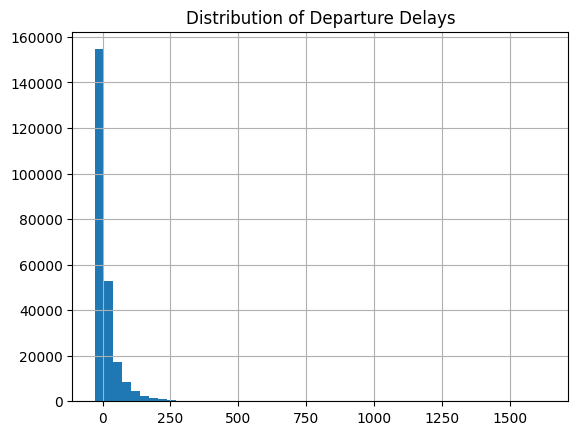

In [ ]:
df['Departure delay (Minutes)'].hist(bins=50)
plt.title("Distribution of Departure Delays")
plt.show()

In [ ]:
df['Delayed'].value_counts(normalize=True)

,proportion
Delayed,
0,0.735548
1,0.264452


In [ ]:
df['Scheduled departure time'] = (
    df['Scheduled departure time']
    .astype(str)
    .str.replace(r'\D', '', regex=True)
    .str.zfill(4)
)

df['Hour'] = pd.to_numeric(df['Scheduled departure time'].str[:2], errors='coerce')

df = df.dropna(subset=['Hour'])
df['Hour'] = df['Hour'].astype(int)

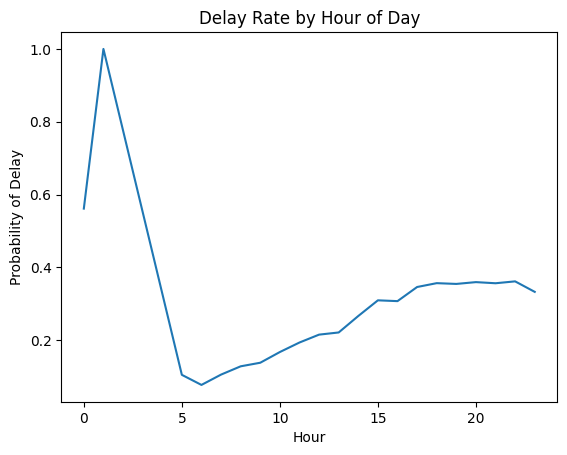

In [ ]:
# Explore how delay rates vary by hour, airport, and day of week
df.groupby('Hour')['Delayed'].mean().plot()
plt.title("Delay Rate by Hour of Day")
plt.ylabel("Probability of Delay")
plt.show()

Flights departing early in the morning tend to have the lowest probability of delay. As the day progresses, the likelihood of delays increases, likely due to accumulated disruptions throughout the day. Evening flights show the highest delay rates, suggesting that delays compound over time. Extremely high delay rates during very early hours may be influenced by low flight volume or data anomalies.

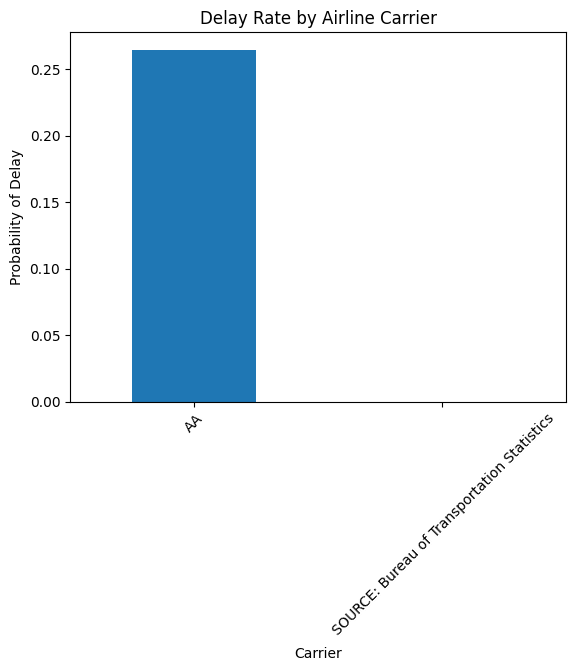

In [ ]:
carrier_delay = df.groupby('Carrier Code')['Delayed'].mean().sort_values(ascending=False)

carrier_delay.plot(kind='bar')
plt.title("Delay Rate by Airline Carrier")
plt.ylabel("Probability of Delay")
plt.xlabel("Carrier")
plt.xticks(rotation=45)
plt.show()

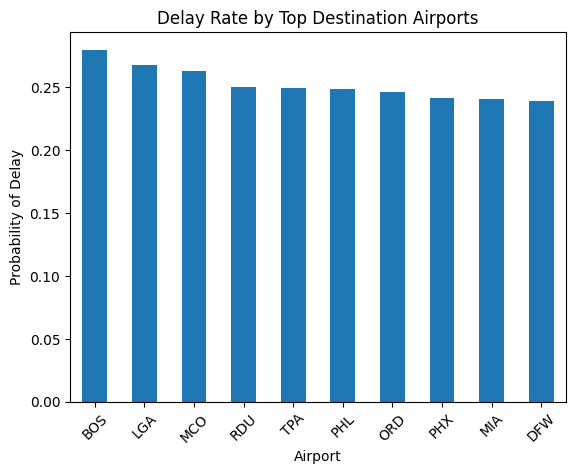

In [ ]:
top_airports = df['Destination Airport'].value_counts().head(10).index

airport_delay = df[df['Destination Airport'].isin(top_airports)] \
    .groupby('Destination Airport')['Delayed'].mean() \
    .sort_values(ascending=False)

airport_delay.plot(kind='bar')
plt.title("Delay Rate by Top Destination Airports")
plt.ylabel("Probability of Delay")
plt.xlabel("Airport")
plt.xticks(rotation=45)
plt.show()

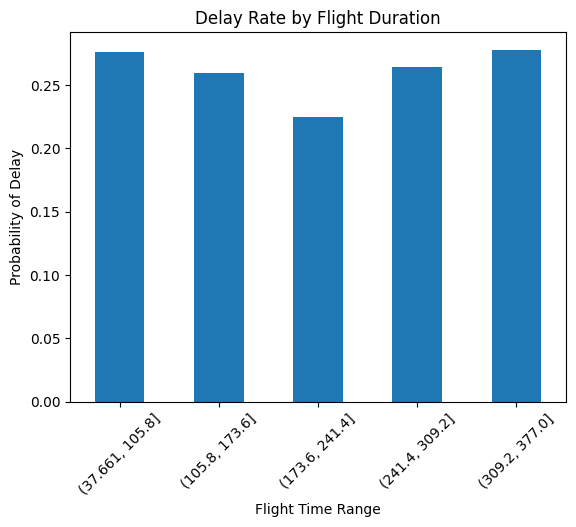

In [ ]:
df['Time Bin'] = pd.cut(df['Scheduled elapsed time (Minutes)'], bins=5)

df.groupby('Time Bin', observed=False)['Delayed'].mean().plot(kind='bar')
plt.title("Delay Rate by Flight Duration")
plt.ylabel("Probability of Delay")
plt.xlabel("Flight Time Range")
plt.xticks(rotation=45)
plt.show()

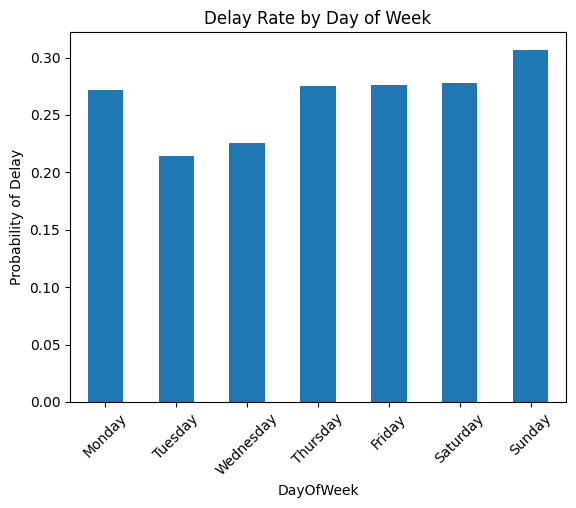

In [ ]:
df['Date'] = pd.to_datetime(df['Date (MM/DD/YYYY)'])
df['DayOfWeek'] = df['Date'].dt.day_name()

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

df.groupby('DayOfWeek')['Delayed'].mean().reindex(order).plot(kind='bar')


plt.title("Delay Rate by Day of Week")
plt.ylabel("Probability of Delay")
plt.xticks(rotation=45)
plt.show()

Several factors appear to influence flight delays. Delay probability increases throughout the day, suggesting that disruptions build up over time. Differences across airports indicate location-specific effects, while flight duration also shows variation in delay likelihood. Delay patterns also vary slightly by day of the week, which may reflect differences in travel demand.

### Feature Selection & Data Leakage Check

Some columns in the dataset directly relate to delays (such as carrier delay, weather delay, NAS delay, security delay, and late aircraft delay). These were excluded from the model because they are not available at the time a passenger is booking a flight as they are only known after a delay has already occurred. Including them would introduce data leakage and make the model unrealistically accurate.

Instead, the model only uses features that would realistically be known before departure, such as scheduled departure hour, day of the week, destination airport, and scheduled flight duration. This keeps the model aligned with the real-world goal of helping passengers make better decisions when booking or planning flights.

In [ ]:
# Prepare selected features for modeling
features = [
    'Hour',
    'DayOfWeek',
    'Destination Airport',
    'Scheduled elapsed time (Minutes)'
]

X = df[features]
y = df['Delayed']

In [ ]:
# Drop rows with missing values
df_model = df.dropna(subset=features)

X = df_model[features]
y = df_model['Delayed']

In [ ]:
# Split the data into train and test sets
X = pd.get_dummies(X, drop_first=True)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Train logistic regression with class balancing
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[20890 15051]
 [ 4638  8299]]
              precision    recall  f1-score   support

           0       0.82      0.58      0.68     35941
           1       0.36      0.64      0.46     12937

    accuracy                           0.60     48878
   macro avg       0.59      0.61      0.57     48878
weighted avg       0.70      0.60      0.62     48878



I started with logistic regression as a baseline model. After applying class weighting and scaling the features with StandardScaler, the model did a better job identifying delayed flights, with recall improving to around 0.64.

This means the model is able to catch more delayed flights, which is important for this project since missing a delay is worse than a false alarm for passengers.

In [ ]:
# Train random forest to capture non-linear patterns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[24988 10953]
 [ 6993  5944]]
              precision    recall  f1-score   support

           0       0.78      0.70      0.74     35941
           1       0.35      0.46      0.40     12937

    accuracy                           0.63     48878
   macro avg       0.57      0.58      0.57     48878
weighted avg       0.67      0.63      0.65     48878



The Random Forest model achieved higher overall accuracy (0.63) compared to logistic regression, but had lower recall for delayed flights (0.46 vs 0.64).

This means that while Random Forest was better at predicting flights overall, it missed more delayed flights compared to logistic regression. Logistic regression, on the other hand, was more effective at identifying delays but at the cost of lower precision.

Since the goal of this project is to help passengers identify flights at risk of delay, recall remains an important metric, and this tradeoff will be considered further in the full model comparison.

In [ ]:
# Apply sample weights to handle class imbalance for Gradient Boosting
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

In [ ]:
# Train gradient boosting for comparison
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_gb = gb.predict(X_test)

print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

[[18823 17118]
 [ 3869  9068]]
              precision    recall  f1-score   support

           0       0.83      0.52      0.64     35941
           1       0.35      0.70      0.46     12937

    accuracy                           0.57     48878
   macro avg       0.59      0.61      0.55     48878
weighted avg       0.70      0.57      0.59     48878



The dataset exhibits class imbalance, which was addressed using sample weighting during model training. The Gradient Boosting model performed the best at identifying delayed flights, achieving a recall of 0.70 for the delayed class.

While its overall accuracy (0.57) is lower than Random Forest, it captures more delayed flights than the other models. This is important because missing a delayed flight is more costly for passengers than incorrectly flagging an on-time flight.

Although precision remains relatively low, the higher recall makes Gradient Boosting the most useful model for this problem. For this reason, it will be selected as the preferred model moving forward.

In [ ]:
# Compare model performance using accuracy, precision, recall, and F1
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

models = {
    "Logistic Regression": model,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, m in models.items():
    if name == "Logistic Regression":
        y_pred = m.predict(X_test_scaled)
    else:
        y_pred = m.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df
results_df.round(3)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.597,0.355,0.641,0.457
1,Random Forest,0.633,0.352,0.459,0.398
2,Gradient Boosting,0.571,0.346,0.701,0.464


The Gradient Boosting model performed the best overall after applying class balancing through sample weights. It achieved the highest recall (0.701), meaning it was the most effective at identifying delayed flights. It also had the highest F1 score (0.464), showing a good balance between precision and recall.

Logistic regression performed well after scaling features with StandardScaler, reaching a recall of 0.641 and an accuracy of 0.597. Scaling helped resolve the convergence issue from earlier and improved its ability to detect delays.

The Random Forest model achieved the highest accuracy (0.633) but had lower recall (0.459), meaning it missed more delayed flights compared to the other models.

Since the goal of this project is to help passengers identify flights at risk of delay, Gradient Boosting is selected as the preferred model because it captures the most delayed flights.

This comparison also highlights the importance of handling class imbalance and scaling, as model performance improved noticeably after these adjustments.

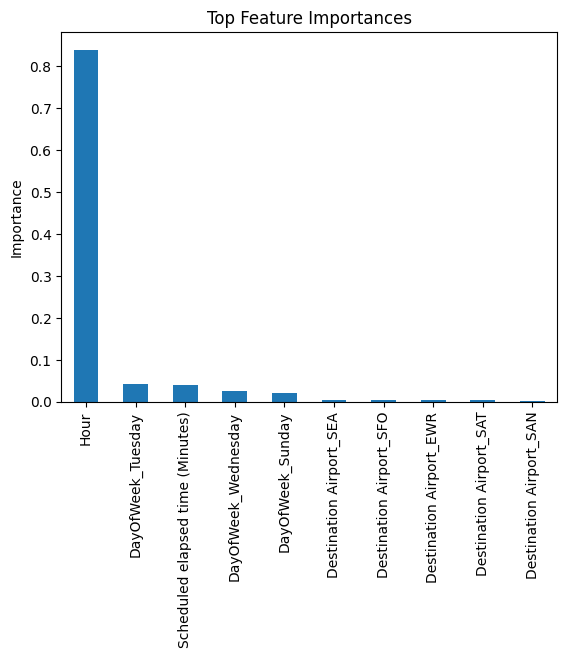

In [ ]:
importance = pd.Series(gb.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Feature Importances")
plt.ylabel("Importance")
plt.show()

The feature importance results show that departure hour is by far the most important predictor of delays, suggesting that time of day plays a major role in delay risk. This makes sense, as delays often build up later in the day.

Scheduled elapsed time also has some influence, indicating that longer flights may be more likely to experience delays.

In comparison, day of week and destination airport have a smaller impact on predictions, meaning they are less important drivers of delay risk in this model.

### Business Recommendations

The results suggest that flights later in the day and those with longer durations are more likely to be delayed. Passengers with tight schedules should consider booking earlier flights or allowing more buffer time for connections to reduce the risk of disruption.

### Deployment & End-User Plan

This model is designed to support passengers during the booking process by estimating the probability of flight delays before departure.

Delay risk predictions could be displayed directly within a flight search or booking interface, allowing users to compare flight options based on delay risk, avoid high-risk options, choose lower-risk departure times, and build safer connection buffers. For example, a passenger booking a connection through Charlotte with a short layover could be flagged if the first flight has a high delay probability, allowing the passenger to choose a safer alternative.

Since flight schedules are known in advance, predictions would be generated in batch rather than in real-time. This makes the system easier to implement and removes strict latency requirements.

In addition to predictions, the model also highlights key factors driving delay risk, helping users better understand how timing and flight characteristics impact reliability.